To work with the tabular data related to osteoporosis prediction and meet the conditions from your dataset (which includes demographic, lifestyle, and medical history features), a good algorithm to use would be Gradient Boosting Decision Trees (GBDT). This includes models like xGBoost or LightGBM, which are powerful for handling structured data with mixed types of features (numerical, categorical).

Steps to implement the algorithm for the tabular data:

1. Data Preprocessing:

  1. Handling Missing Values: Fill or drop missing values based on the nature of the data (e.g., mean/median for numerical, mode for categorical).
  2. Encoding Categorical Variables: Convert categorical variables (e.g., Gender, Smoker, Occupation) into numerical format using techniques like One-Hot Encoding.
  3. Feature Scaling: Apply scaling to numeric features (e.g., Age, BMI, Height) if needed for the algorithm to converge faster.
2. xGBoost Algorithm: xGBoost is an efficient and flexible implementation of GBDT and works well for tabular data, giving high accuracy with feature importance visualization.

In [1]:
# Install xGBoost if not already installed
# !pip install xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.9 MB 1.7 MB/s eta 0:01:15
   ---------------------------------------- 1.0/124.9 MB 1.9 MB/s eta 0:01:05
    --------------------------------------- 1.6/124.9 MB 2.1 MB/s eta 0:00:59
    --------------------------------------- 2.1/124.9 MB 2.1 MB/s eta 0:01:00
    --------------------------------------- 2.4/124.9 MB 2.0 MB/s eta 0:01:03
    --------------------------------------- 2.6/124.9 MB 1.8 MB/s eta 0:01:07
    --------------------------------------- 2.9/124.9 MB 1.8 MB/s eta 0:01:10
   - -------------------------------------- 3.4/124.9 MB 1.8 MB/s eta 0:01:09
   - -------------------------------------- 3.7/124.9 MB 1.8 MB/s eta 0:01:08
   - -------------------------------------- 3.9/124.9 MB 1.8 MB/s eta 0:01:09
   - -------------------------------------- 4.5/124.9 MB 1.8 MB/s eta 0:01:08


In [8]:
# %pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


Why xGBoost?
High accuracy: It handles structured/tabular data very efficiently.
Handles missing data: xGBoost can handle missing data directly, which might be useful for your medical dataset.
Feature Importance: It provides insights into which features are most important for the prediction.

In [1]:
import pandas as pd
import xgboost as xgb
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [55]:
# Load the dataset (your dataset may need specific paths)
data = pd.read_excel(r'E:\DrBones\dataset\tabledata\patient details2.xlsx')

In [56]:
# Preprocessing: handle missing values
data.fillna(method='ffill', inplace=True)  # or any method suited to your data
# Check and clean column names (if needed)
data.columns = data.columns.str.strip()
# Fill any missing values
data = data.fillna('False')

C:\Users\cmjot\AppData\Local\Temp\ipykernel_32336\1136419579.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)  # or any method suited to your data


In [57]:
# Identify columns to encode (categorical)
categorical_columns = ['Patient Id', 'Joint Pain:', 'Gender', 'Menopause Age', 'Smoker', 'Alcoholic', 
                       'Diabetic', 'Hypothyroidism', 'Seizer Disorder', 'Estrogen Use', 'Occupation',
                       'History of Fracture', 'Dialysis:', 'Family History of Osteoporosis', 'Daily Eating habits',
                       'Medical History', 'Site', 'Obesity']

# Convert all categorical columns to strings before encoding
data[categorical_columns] = data[categorical_columns].astype(str)


In [58]:
# Encode categorical features using LabelEncoder
le = LabelEncoder()

for col in categorical_columns:
    data[col] = le.fit_transform(data[col])

In [59]:
# Select features (x) and target (y)
x = data.drop(['Diagnosis'], axis=1)  # Drop the target column
y = data['Diagnosis']  # Target column

In [60]:
# Split data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Drop rows with NaN values
x_train.dropna(inplace=True)
y_train.dropna(inplace=True)

# Or fill NaN values with a specific value
x_train.fillna(0, inplace=True)  # Replace 0 with an appropriate value if needed
y_train.fillna(0,inplace=True)

In [62]:
# Convert columns with numeric values stored as strings to actual numeric types
data['Number of Pregnancies'] = pd.to_numeric(data['Number of Pregnancies'], errors='coerce')  # Converts invalid parsing to NaN

# Convert 'Number of Pregnancies' to numeric and handle NaN values
x_test['Number of Pregnancies'] = pd.to_numeric(x_test['Number of Pregnancies'], errors='coerce')
# Fill NaN values by reassigning the column
x_train['Number of Pregnancies'] = x_train['Number of Pregnancies'].fillna(0)

# Convert any remaining object columns
for column in x_test.columns:
    if x_test[column].dtype == 'object':
        x_test[column] = pd.to_numeric(x_test[column], errors='coerce')
        x_test[column] = x_test[column].fillna(0)  # Reassign after filling NaN

In [68]:
# Initialize LabelEncoder
le = LabelEncoder()

# Encode the target variable y_train and y_test
y_train_encoded = le.fit_transform(y_train)  # Convert 'normal', 'osteopenia', 'osteoporosis' to integers
y_test_encoded = le.transform(y_test)

# Check if the classes are encoded correctly
print("Classes found:", le.classes_)  # Should print ['normal', 'osteopenia', 'osteoporosis']


Classes found: ['normal' 'osteopenia' 'osteoporosis']


In [66]:
# Inspect the column for invalid values
print(data['Number of Pregnancies'].unique())

# Convert 'Number of Pregnancies' column to numeric, force invalid parsing to NaN
data['Number of Pregnancies'] = pd.to_numeric(data['Number of Pregnancies'], errors='coerce')

# Check for missing values after conversion
print(data['Number of Pregnancies'].isna().sum())

# Handle NaN values (if any) by filling them with 0, the mean, or dropping the rows
data['Number of Pregnancies'].fillna(0, inplace=True)  # Example: Filling with 0

# Verify that the column is now numeric
print(data['Number of Pregnancies'].dtype)

# Repeat similar steps for other numeric columns if necessary
numeric_columns = ['Menopause Age', 'Age']
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')
    data[col].fillna(data[col].mean(), inplace=True)  # Example: Filling missing values with the mean



[0. 3. 5. 4. 1. 7. 2. 6.]
0
float64


C:\Users\cmjot\AppData\Local\Temp\ipykernel_32336\124586357.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Number of Pregnancies'].fillna(0, inplace=True)  # Example: Filling with 0
C:\Users\cmjot\AppData\Local\Temp\ipykernel_32336\124586357.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [30]:
# Create an xGBoost model
model = xgb.XGBClassifier(
    objective='multi:softmax',  # for multi-class classification
    num_class=3,  # number of classes (normal, osteoporosis, osteopenia)
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

In [69]:
# Train the model
model.fit(x_train, y_train_encoded)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Number of Pregnancies: object

In [39]:
# print(x_train.dtypes)

S.No                              float64
Patient Id                          int32
Joint Pain:                         int32
Gender                              int32
Age                               float64
Menopause Age                       int32
height  (meter)                   float64
Weight (KG)                       float64
Smoker                              int32
Alcoholic                           int32
Diabetic                            int32
Hypothyroidism                      int32
Number of Pregnancies              object
Seizer Disorder                     int32
Estrogen Use                        int32
Occupation                          int32
History of Fracture                 int32
Dialysis:                           int32
Family History of Osteoporosis      int32
Maximum Walking distance (km)     float64
Daily Eating habits                 int32
Medical History                     int32
T-score Value                     float64
Z-Score Value                     

In [32]:
# # Convert 'Number of Pregnancies' to numeric, with errors coerced to NaN
# x_train['Number of Pregnancies'] = pd.to_numeric(x_train['Number of Pregnancies'], errors='coerce')

# # Check for NaN values
# print(x_train['Number of Pregnancies'].isna().sum())


1


In [12]:
# Make predictions
y_pred = model.predict(x_test)

NotFittedError: need to call fit or load_model beforehand

In [50]:
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 100.00%


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

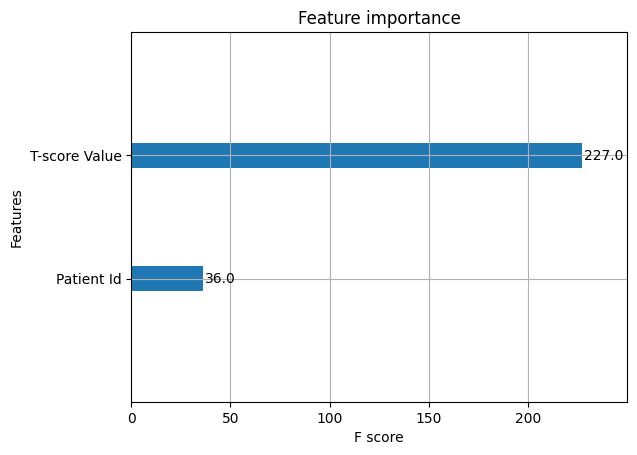

In [51]:
# Feature importance
xgb.plot_importance(model)

This method will allow you to leverage all the conditions in your dataset (like age, menopause age, height, smoker, alcohol use, medical history, etc.) for predicting osteoporosis. Since you are aiming for a hybrid model, you can further combine this approach with your MobileNet model for x-ray images to create a more robust prediction pipeline.

In [ ]:
import joblib

# Save the model to a file
model_filename = 'xgboost_model.joblib'
joblib.dump(model, )

print(f"Model saved to {model_filename}")
